# Mid-Course Project

Hi there,

I’m the host of a movie reviews podcast and I’m currently making an episode about movie review aggregators.

I found this data set from Rotten Tomatoes (inside the .ipynb file that I’ve attached). Could you dig into the data and share any interesting insights that you find? My audience loves fun facts about movies.

Thank you!\
KP

## 0. Read in the Data

In [2]:
# rotten tomatoes movie data set from Maven's data playground
import pandas as pd

movies = pd.read_csv('data/Rotten Tomatoes Movies.csv')
movies.head(3)

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0
1,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0
2,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0


In [3]:
# subset of the data
movies = movies[['movie_title', 'rating', 'genre', 'in_theaters_date','runtime_in_minutes',
                 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count']]
movies.head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0
1,Please Give,R,Comedy,2010-04-30,90.0,86,140,64.0,11567.0
2,10,R,"Comedy, Romance",1979-10-05,118.0,68,22,53.0,14670.0
3,12 Angry Men (Twelve Angry Men),NR,"Classics, Drama",1957-04-13,95.0,100,51,97.0,105000.0
4,"20,000 Leagues Under The Sea",G,"Action & Adventure, Drama, Kids & Family",1954-01-01,127.0,89,27,74.0,68860.0


## 1. Explore the Data

How many movies are in this data set?

In [4]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16638 non-null  str    
 1   rating              16638 non-null  str    
 2   genre               16621 non-null  str    
 3   in_theaters_date    15823 non-null  str    
 4   runtime_in_minutes  16483 non-null  float64
 5   tomatometer_rating  16638 non-null  int64  
 6   tomatometer_count   16638 non-null  int64  
 7   audience_rating     16386 non-null  float64
 8   audience_count      16386 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 1.1 MB


In [5]:
movies.shape

(16638, 9)

In [6]:
movies.count()

movie_title           16638
rating                16638
genre                 16621
in_theaters_date      15823
runtime_in_minutes    16483
tomatometer_rating    16638
tomatometer_count     16638
audience_rating       16386
audience_count        16386
dtype: int64

In [7]:
movies.describe()

,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
count,16483.000000,16638.000000,16638.000000,16386.000000,1.638600e+04
mean,102.391494,60.466522,56.607104,60.470829,1.524797e+05
std,25.028011,28.587230,66.383800,20.462368,1.817736e+06
min,1.000000,0.000000,5.000000,0.000000,5.000000e+00
25%,90.000000,38.000000,12.000000,45.000000,8.642500e+02
50%,99.000000,66.000000,28.000000,62.000000,4.876500e+03
75%,111.000000,86.000000,76.000000,77.000000,2.875200e+04
max,2000.000000,100.000000,497.000000,100.000000,3.579764e+07


Filter the data to only include movies that came out in 2010 or later. How many movies are in this new data set?

In [8]:
movies.head(2)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0
1,Please Give,R,Comedy,2010-04-30,90.0,86,140,64.0,11567.0


In [106]:
movies['in_theaters_date'] = pd.to_datetime(movies['in_theaters_date'])

In [107]:
movies.dtypes

movie_title                      str
rating                           str
genre                            str
in_theaters_date      datetime64[us]
runtime_in_minutes           float64
tomatometer_rating             int64
tomatometer_count              int64
audience_rating              float64
audience_count               float64
dtype: object

In [117]:
movies_after_2010 = movies[movies['in_theaters_date'] > '2009-12-31'].reset_index(drop=True)

In [118]:
movies_after_2010.count()

movie_title           6053
rating                6053
genre                 6048
in_theaters_date      6053
runtime_in_minutes    5930
tomatometer_rating    6053
tomatometer_count     6053
audience_rating       5956
audience_count        5956
dtype: int64

In [119]:
# alternative solution - just with year
movies[movies['in_theaters_date'].dt.year >= 2010].count()

movie_title           6053
rating                6053
genre                 6048
in_theaters_date      6053
runtime_in_minutes    5930
tomatometer_rating    6053
tomatometer_count     6053
audience_rating       5956
audience_count        5956
dtype: int64

In [120]:
movies_after_2010.shape

(6053, 9)

Find the highest rated movies according to both critics (*tomatometer_rating*) and the general audience (*audience_rating*).

In [121]:
movies_after_2010.sort_values('tomatometer_rating', ascending=False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
2198,High Ground,NR,"Documentary, Special Interest",2012-11-02,91.0,100,8,74.0,295.0
3926,Rodney King,NR,Drama,2017-04-28,52.0,100,9,NaN,NaN
53,11:55,NR,Drama,2017-06-09,80.0,100,5,81.0,378.0
4300,Stations of the Elevated,NR,"Documentary, Musical & Performing Arts, Specia...",2014-10-17,45.0,100,8,33.0,124.0
484,Among Wolves,NR,Documentary,2019-02-08,94.0,100,12,91.0,106.0


In [122]:
movies_after_2010.sort_values('audience_rating', ascending=False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
5156,The Most Dangerous Year,NR,Documentary,2019-04-12,90.0,91,11,100.0,40.0
1127,Charm City,NR,Documentary,2018-10-19,108.0,100,16,100.0,24.0
5143,The Miners' Hymns,NR,"Documentary, Drama, Special Interest",2012-02-08,52.0,100,10,100.0,148.0
1041,Calling All Earthlings,NR,Documentary,2018-06-29,74.0,58,12,100.0,34.0
2133,Haunt,R,"Horror, Mystery & Suspense",2019-09-13,92.0,68,38,100.0,7.0


In [39]:
mask = (movies_after_2010['tomatometer_rating'] > 80) & (movies_after_2010['audience_rating'] > 80)

In [40]:
movies_after_2010[mask]

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
53,11:55,NR,Drama,2017-06-09,80.0,100,5,81.0,378.0
60,The Wrecking Crew,PG,"Documentary, Musical & Performing Arts",2015-03-13,95.0,94,70,84.0,5302.0
81,Warrior,PG-13,"Action & Adventure, Drama",2011-09-09,139.0,83,189,92.0,59171.0
82,A Prophet (Un prophete),R,"Art House & International, Drama",2010-02-26,155.0,97,157,89.0,24938.0
84,Despicable Me,PG,"Animation, Comedy, Kids & Family",2010-07-09,95.0,81,197,82.0,267208.0
...,...,...,...,...,...,...,...,...,...
5999,X-Men: Days of Future Past,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-05-23,131.0,90,318,91.0,276699.0
6000,X-Men: First Class,PG-13,"Action & Adventure, Drama, Science Fiction & F...",2011-06-03,132.0,86,290,87.0,184330.0
6028,Your Name. (Kimi No Na Wa.),PG,"Animation, Drama, Romance",2017-04-07,106.0,97,111,94.0,11716.0
6046,Zindagi Na Milegi Dobara,NR,"Art House & International, Comedy, Drama",2011-05-27,148.0,91,11,86.0,3858.0


These top movies seem to have very few critics and audience members writing the reviews. We want to look at only the most popular movies. Filter the movies data set to only include movies that have 100k+ audience ratings. How many movies are in this data set?

In [43]:
movies_after_2010[movies_after_2010['audience_count'] > 100000].sort_values('audience_rating', ascending=False)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
6052,Zootopia,PG,"Action & Adventure, Animation, Comedy",2016-03-04,108.0,97,279,92.0,100946.0
5034,The King's Speech,PG-13,Drama,2010-11-26,118.0,95,292,92.0,144306.0
1062,Captain America: The Winter Soldier,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-04-04,136.0,90,292,92.0,281524.0
2069,Guardians of the Galaxy,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-08-01,121.0,91,316,92.0,254717.0
5129,The Martian,PG-13,Science Fiction & Fantasy,2015-10-02,164.0,91,361,91.0,131093.0
...,...,...,...,...,...,...,...,...,...
2811,Legion,R,"Action & Adventure, Horror, Mystery & Suspense",2010-01-22,100.0,19,104,31.0,312684.0
2753,The Last Airbender,PG,"Action & Adventure, Kids & Family, Science Fic...",2010-07-01,103.0,5,189,30.0,321915.0
1142,Chernobyl Diaries,R,"Drama, Horror",2012-05-25,86.0,19,89,28.0,141874.0
2573,Jonah Hex,PG-13,"Action & Adventure, Drama, Horror, Western",2010-06-18,84.0,12,150,20.0,170670.0


Find the highest rated **popular** movies according to both critics (*tomatometer_rating*) and the general audience (*audience_rating*).

In [44]:
movies_after_2010.describe()

,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
count,5930.000000,6053.000000,6053.000000,5956.000000,5.956000e+03
mean,101.069309,60.048075,74.716504,57.333109,1.999020e+04
std,17.891544,28.328714,82.857754,20.243269,6.484518e+04
min,15.000000,0.000000,5.000000,0.000000,5.000000e+00
25%,90.000000,38.000000,15.000000,42.000000,3.440000e+02
50%,98.000000,66.000000,38.000000,58.000000,1.717500e+03
75%,110.000000,85.000000,112.000000,74.000000,1.128850e+04
max,480.000000,100.000000,497.000000,100.000000,2.373625e+06


In [47]:
mask = (movies_after_2010['audience_count'] > 100000) & (movies_after_2010['tomatometer_count'] > 200)

In [52]:
popular_movies = movies_after_2010[mask].sort_values('tomatometer_rating', ascending=False)

In [53]:
popular_movies.count()

movie_title           189
rating                189
genre                 189
in_theaters_date      189
runtime_in_minutes    189
tomatometer_rating    189
tomatometer_count     189
audience_rating       189
audience_count        189
dtype: int64

In [123]:
movies_popular = movies_after_2010[movies_after_2010['audience_count'] > 100000]

In [125]:
popular_movies.describe()

,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
count,189.000000,189.000000,189.000000,189.000000,1.890000e+02,189.000000,189.000000,189.000000
mean,123.322751,69.587302,269.746032,71.476190,2.402024e+05,0.068783,0.608466,0.243386
std,19.689250,22.002153,56.371290,15.860285,2.257435e+05,0.253757,0.489390,0.430266
min,83.000000,9.000000,201.000000,18.000000,1.003720e+05,0.000000,0.000000,0.000000
25%,108.000000,55.000000,225.000000,60.000000,1.291620e+05,0.000000,0.000000,0.000000
50%,122.000000,75.000000,255.000000,75.000000,1.791510e+05,0.000000,1.000000,0.000000
75%,137.000000,89.000000,298.000000,85.000000,2.649680e+05,0.000000,1.000000,0.000000
max,179.000000,99.000000,454.000000,92.000000,2.373625e+06,1.000000,1.000000,1.000000


In [126]:
movies_popular.shape

(316, 9)

In [127]:
movies_popular.sort_values('tomatometer_rating', ascending=False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
2280,How to Train Your Dragon,PG,"Animation, Kids & Family, Science Fiction & Fa...",2010-03-26,98.0,99,208,91.0,312342.0
2431,Inside Out,PG,"Animation, Kids & Family",2015-06-19,94.0,98,357,89.0,136125.0
5606,Toy Story 3,G,"Animation, Comedy, Kids & Family",2010-06-18,103.0,98,305,89.0,606931.0
6052,Zootopia,PG,"Action & Adventure, Animation, Comedy",2016-03-04,108.0,97,279,92.0,100946.0
3010,Mad Max: Fury Road,R,"Action & Adventure, Science Fiction & Fantasy",2015-05-15,120.0,97,410,85.0,127428.0


In [128]:
movies_popular.sort_values('audience_rating', ascending=False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
6052,Zootopia,PG,"Action & Adventure, Animation, Comedy",2016-03-04,108.0,97,279,92.0,100946.0
5034,The King's Speech,PG-13,Drama,2010-11-26,118.0,95,292,92.0,144306.0
1062,Captain America: The Winter Soldier,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-04-04,136.0,90,292,92.0,281524.0
2069,Guardians of the Galaxy,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-08-01,121.0,91,316,92.0,254717.0
5129,The Martian,PG-13,Science Fiction & Fantasy,2015-10-02,164.0,91,361,91.0,131093.0


A lot of these popular movies seem to have a PG or PG-13 rating. How many movies fall under each type of rating?

*Use this popular movies data set going forward in this notebook.*

In [56]:
popular_movies.groupby('rating')['movie_title'].count()

rating
G          2
PG        17
PG-13    112
R         58
Name: movie_title, dtype: int64

In [129]:
movies_popular.groupby('rating')['movie_title'].count()

rating
G          5
PG        51
PG-13    160
R        100
Name: movie_title, dtype: int64

In [130]:
movies_popular['rating'].value_counts()

rating
PG-13    160
R        100
PG        51
G          5
Name: count, dtype: int64

What is the average audience rating for each movie rating type? Which rating type is most highly rated?

In [61]:
popular_movies.groupby('rating')['audience_rating'].mean().sort_values(ascending=False)

rating
PG       76.176471
PG-13    71.053571
R        71.000000
G        69.000000
Name: audience_rating, dtype: float64

In [131]:
movies_popular.groupby('rating')['audience_rating'].mean().sort_values(ascending=False)

rating
PG-13    67.293750
PG       66.823529
G        66.200000
R        63.010000
Name: audience_rating, dtype: float64

In [63]:
popular_movies.groupby('rating')['tomatometer_rating'].mean().sort_values(ascending=False)

rating
PG       78.764706
R        71.965517
G        68.500000
PG-13    66.982143
Name: tomatometer_rating, dtype: float64

## 2. Create New Columns

Create a column in the DataFrame called 'Animation' and return a 1 if a movie is an 'Animation' movie and 0 otherwise. Do the same for *Action & Adventure* and *Comedy*.

*Hint: use np.where and str.contains*

In [80]:
popular_movies.head(2)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
2280,How to Train Your Dragon,PG,"Animation, Kids & Family, Science Fiction & Fa...",2010-03-26,98.0,99,208,91.0,312342.0,1,0,0
2431,Inside Out,PG,"Animation, Kids & Family",2015-06-19,94.0,98,357,89.0,136125.0,1,0,0


In [68]:
import numpy as np

In [140]:
# create as new data frame!!! (without .copy() it creates view of dataframe. Now it is its own dataframe I can modify
movies_popular = movies_after_2010[movies_after_2010['audience_count'] > 100000].copy()

In [141]:
movies_popular['Animation'] = np.where(movies_popular['genre'].str.contains('Animation'), 1, 0)

In [142]:
movies_popular['Action & Adventure'] = np.where(movies_popular['genre'].str.contains('Action & Adventure'), 1, 0)

In [143]:
movies_popular['Comedy'] = np.where(movies_popular['genre'].str.contains('Comedy'), 1, 0)

In [144]:
movies_popular.head(3)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0,0,1,1
12,Tron Legacy,PG,"Action & Adventure, Science Fiction & Fantasy",2010-12-17,125.0,51,239,63.0,171385.0,0,1,0
18,The Last Song,PG,"Drama, Kids & Family, Romance",2010-03-31,107.0,20,118,66.0,160777.0,0,0,0


In [145]:
movies_popular.describe()

,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
count,316,316.000000,316.000000,316.000000,316.000000,3.160000e+02,316.000000,316.000000,316.000000
mean,2012-07-23 13:53:55.443038,115.072785,60.000000,221.325949,65.844937,2.135527e+05,0.098101,0.547468,0.329114
min,2010-01-08 00:00:00,83.000000,4.000000,36.000000,18.000000,1.003720e+05,0.000000,0.000000,0.000000
25%,2010-11-22 18:00:00,100.000000,41.750000,165.750000,52.750000,1.264555e+05,0.000000,0.000000,0.000000
50%,2012-06-18 12:00:00,110.500000,65.500000,217.000000,66.000000,1.623600e+05,0.000000,1.000000,0.000000
75%,2013-08-24 18:00:00,128.250000,81.000000,268.250000,82.000000,2.432478e+05,0.000000,1.000000,1.000000
max,2017-12-15 00:00:00,179.000000,99.000000,454.000000,92.000000,2.373625e+06,1.000000,1.000000,1.000000
std,NaN,19.644081,25.304495,76.978196,16.596557,1.848712e+05,0.297923,0.498531,0.470637


In [ ]:
popular_movies['Animation'] = np.where(popular_movies['genre'].str.contains('Animation'), 1, 0)

In [75]:
popular_movies['Action & Adventure'] = np.where(popular_movies['genre'].str.contains('Action & Adventure'), 1, 0)

In [77]:
popular_movies['Comedy'] = np.where(popular_movies['genre'].str.contains('Comedy'), 1, 0)

Create a table where each row is a rating, each column is a genre and each value is the number of movies of that particular rating and genre. What insights do you gather?

In [82]:
pd.pivot_table(popular_movies, values='movie_title', index='rating', columns='genre', aggfunc='count')

genre,Action & Adventure,"Action & Adventure, Animation, Comedy","Action & Adventure, Animation, Comedy, Kids & Family","Action & Adventure, Animation, Kids & Family","Action & Adventure, Comedy","Action & Adventure, Comedy, Drama","Action & Adventure, Comedy, Drama, Horror","Action & Adventure, Comedy, Mystery & Suspense","Action & Adventure, Comedy, Mystery & Suspense, Science Fiction & Fantasy","Action & Adventure, Comedy, Romance",...,"Drama, Science Fiction & Fantasy, Romance","Drama, Science Fiction & Fantasy, Special Interest, Romance","Drama, Sports & Fitness","Drama, Western","Horror, Mystery & Suspense",Mystery & Suspense,"Mystery & Suspense, Science Fiction & Fantasy","Mystery & Suspense, Science Fiction & Fantasy, Romance",Science Fiction & Fantasy,"Science Fiction & Fantasy, Romance"
rating,,,,,,,,,,,,,,,,,,,,,
G,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PG,NaN,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
PG-13,5.0,NaN,NaN,NaN,3.0,NaN,NaN,1.0,1.0,1.0,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0
R,3.0,NaN,NaN,NaN,3.0,1.0,1.0,NaN,NaN,NaN,...,NaN,1.0,1.0,1.0,3.0,1.0,NaN,NaN,NaN,NaN


In [146]:
movies_popular.groupby('rating')[['Animation', 'Action & Adventure', 'Comedy']].sum()

,Animation,Action & Adventure,Comedy
rating,,,
G,5,3,5
PG,26,27,29
PG-13,0,102,35
R,0,41,35


Find the average critic and audience rating for an Animation movie vs a non-Animation movie. Do the same for Action & Adventure and Comedy. What insights do you gather?

In [83]:
popular_movies.head(2)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
2280,How to Train Your Dragon,PG,"Animation, Kids & Family, Science Fiction & Fa...",2010-03-26,98.0,99,208,91.0,312342.0,1,0,0
2431,Inside Out,PG,"Animation, Kids & Family",2015-06-19,94.0,98,357,89.0,136125.0,1,0,0


In [92]:
popular_movies.groupby('Animation')['tomatometer_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Animation,,,,,,,,
0,176.0,68.420455,21.845809,9.0,53.0,73.0,86.0,97.0
1,13.0,85.384615,18.278122,39.0,88.0,90.0,97.0,99.0


In [93]:
popular_movies.groupby('Animation')['audience_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Animation,,,,,,,,
0,176.0,70.857955,15.778367,18.0,59.75,74.0,85.0,92.0
1,13.0,79.846154,15.126391,49.0,76.00,87.0,89.0,92.0


In [94]:
popular_movies.groupby('Action & Adventure')['tomatometer_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Action & Adventure,,,,,,,,
0,74.0,73.756757,20.748204,15.0,66.0,79.0,90.0,99.0
1,115.0,66.904348,22.452669,9.0,51.0,72.0,85.5,97.0


In [95]:
popular_movies.groupby('Action & Adventure')['audience_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Action & Adventure,,,,,,,,
0,74.0,72.189189,16.460559,33.0,60.0,76.0,86.0,92.0
1,115.0,71.017391,15.517383,18.0,60.0,74.0,85.0,92.0


In [96]:
popular_movies.groupby('Comedy')['tomatometer_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Comedy,,,,,,,,
0,143.0,69.363636,22.504004,9.0,53.00,74.0,89.00,99.0
1,46.0,70.282609,20.584420,15.0,63.75,77.0,83.75,98.0


In [97]:
popular_movies.groupby('Comedy')['audience_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Comedy,,,,,,,,
0,143.0,72.454545,15.834410,18.0,61.00,76.0,85.50,92.0
1,46.0,68.434783,15.723517,43.0,54.25,71.0,83.75,92.0


In [147]:
movies_popular.groupby('Animation')[['tomatometer_rating', 'audience_rating']].mean()

,tomatometer_rating,audience_rating
Animation,,
0,58.340351,64.831579
1,75.258065,75.161290


In [148]:
movies_popular.groupby('Action & Adventure')[['tomatometer_rating', 'audience_rating']].mean()

,tomatometer_rating,audience_rating
Action & Adventure,,
0,59.111888,65.391608
1,60.734104,66.219653


In [149]:
movies_popular.groupby('Comedy')[['tomatometer_rating', 'audience_rating']].mean()

,tomatometer_rating,audience_rating
Comedy,,
0,62.169811,67.353774
1,55.576923,62.769231


## 3. Visualize the Data

Create a pair plot from the popular movies DataFrame.

In [98]:
import seaborn as sns

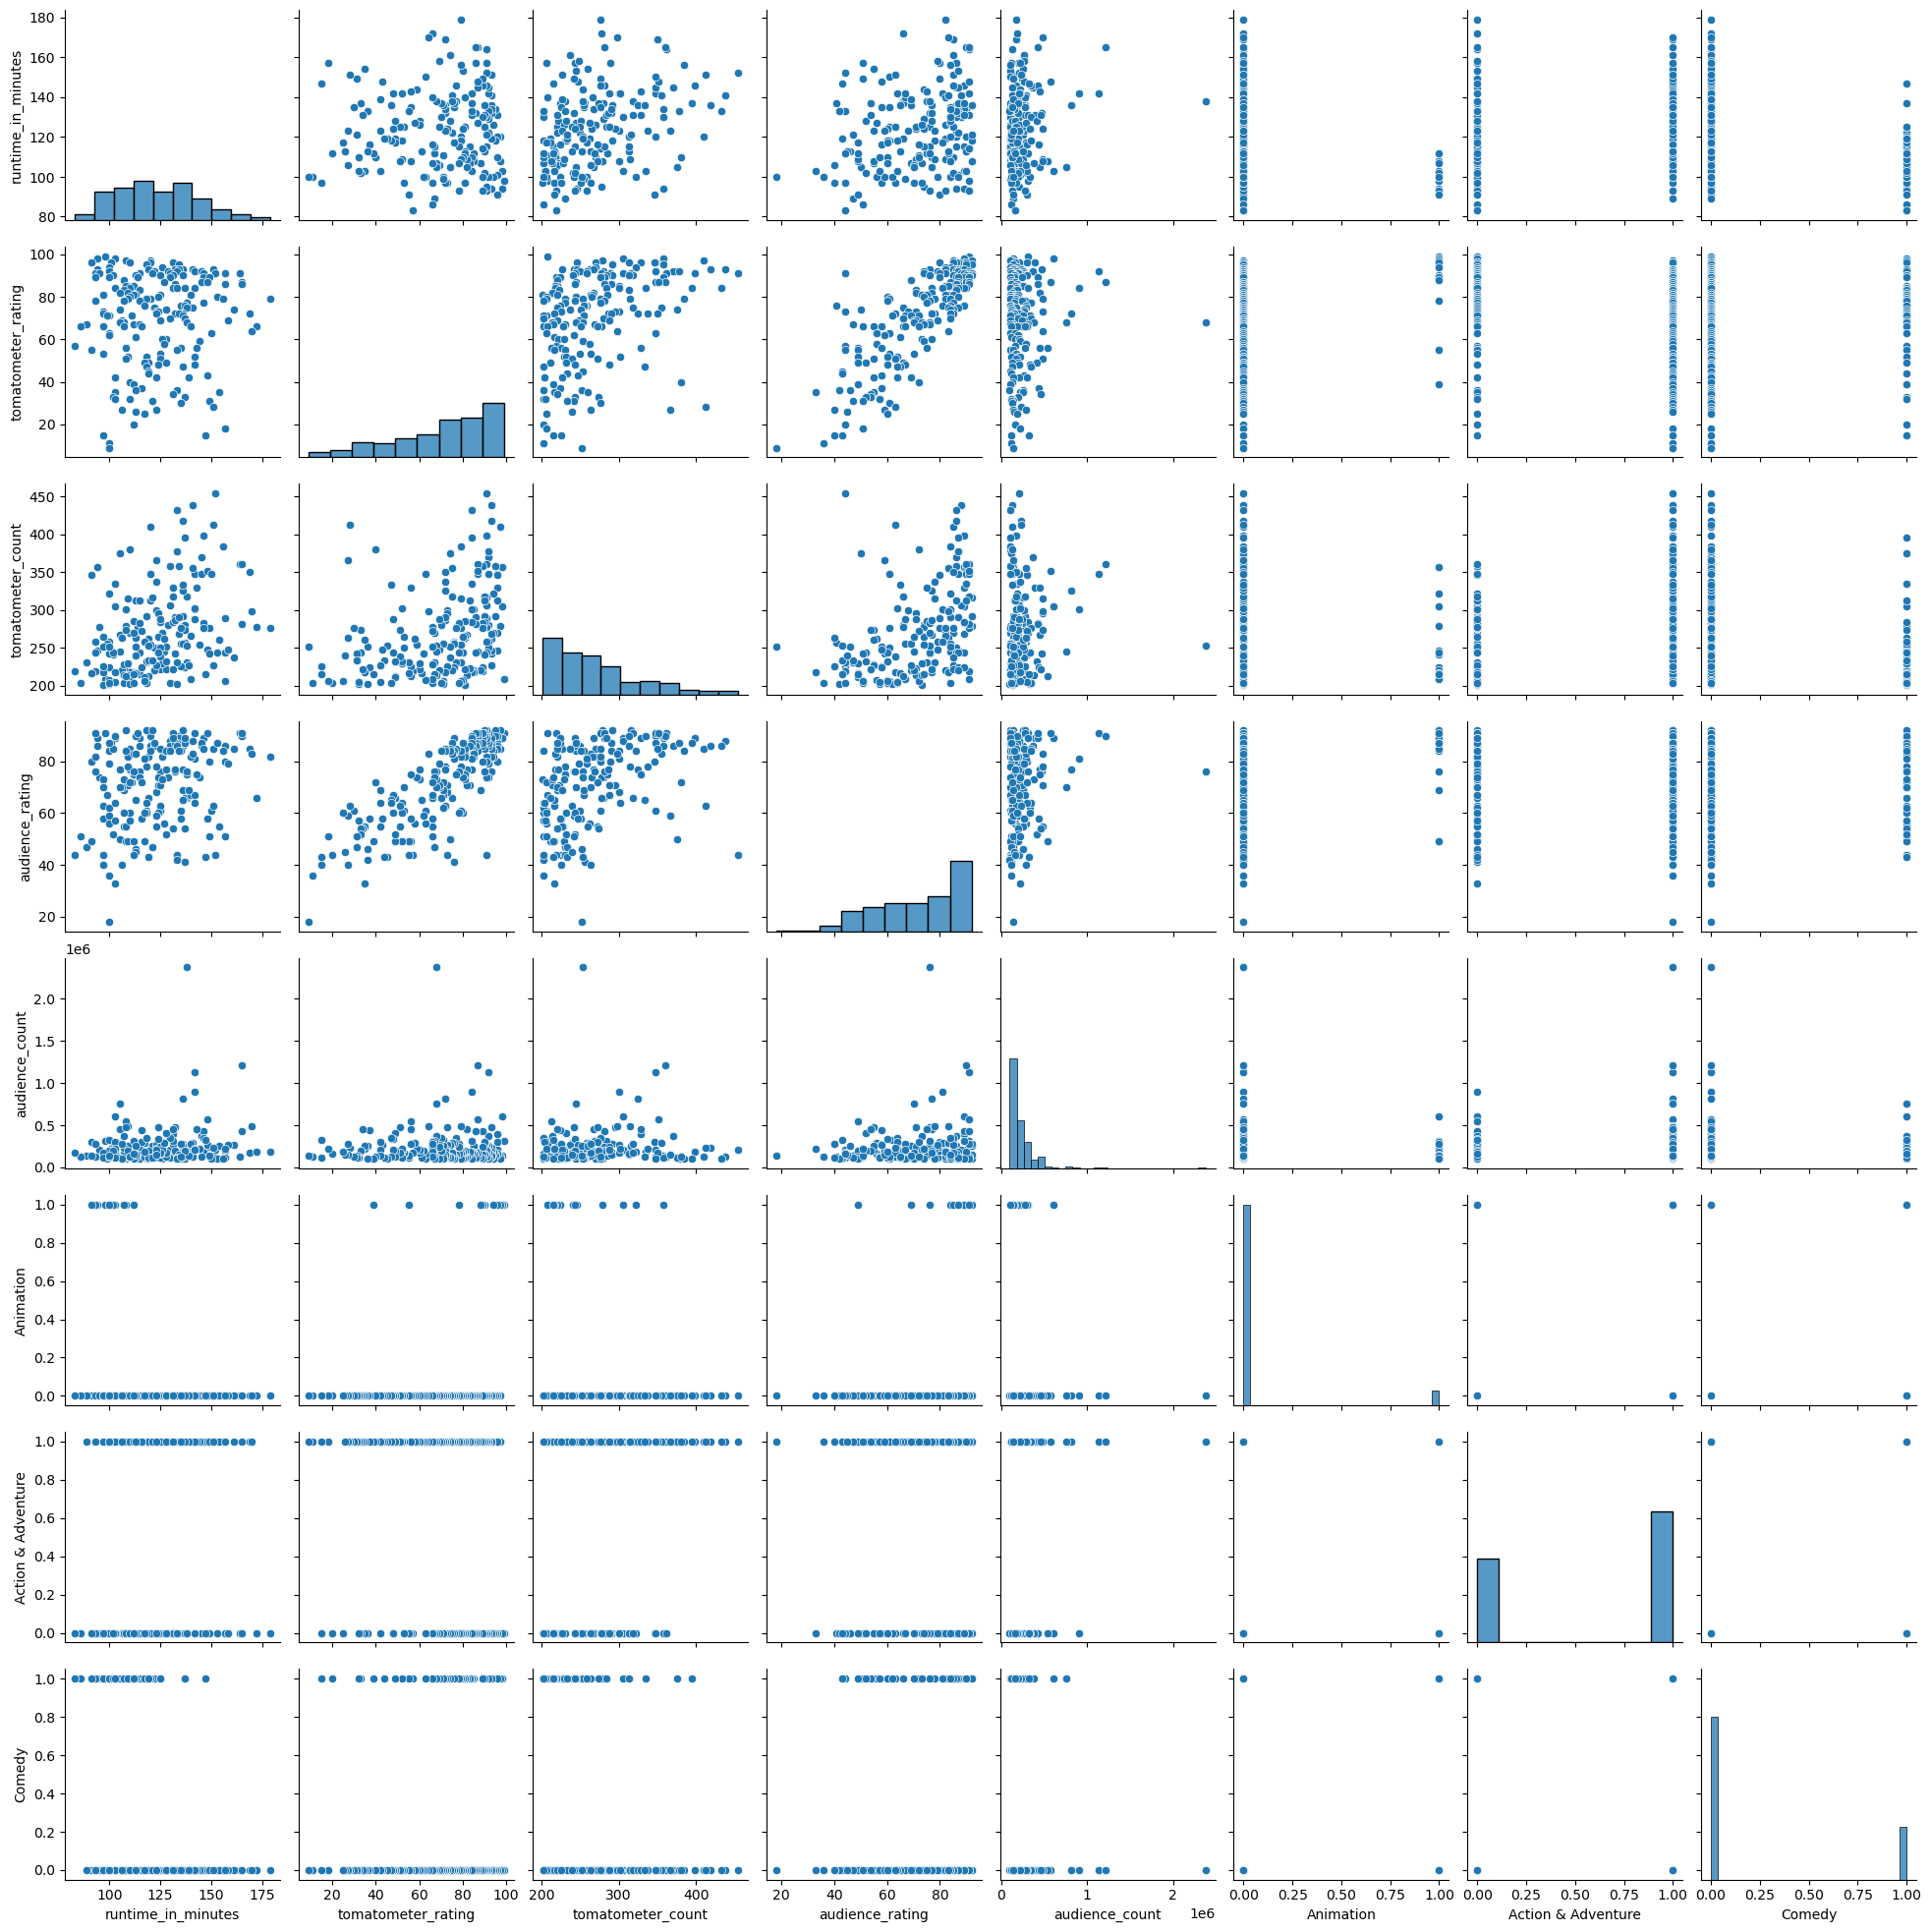

In [99]:
sns.pairplot(popular_movies)

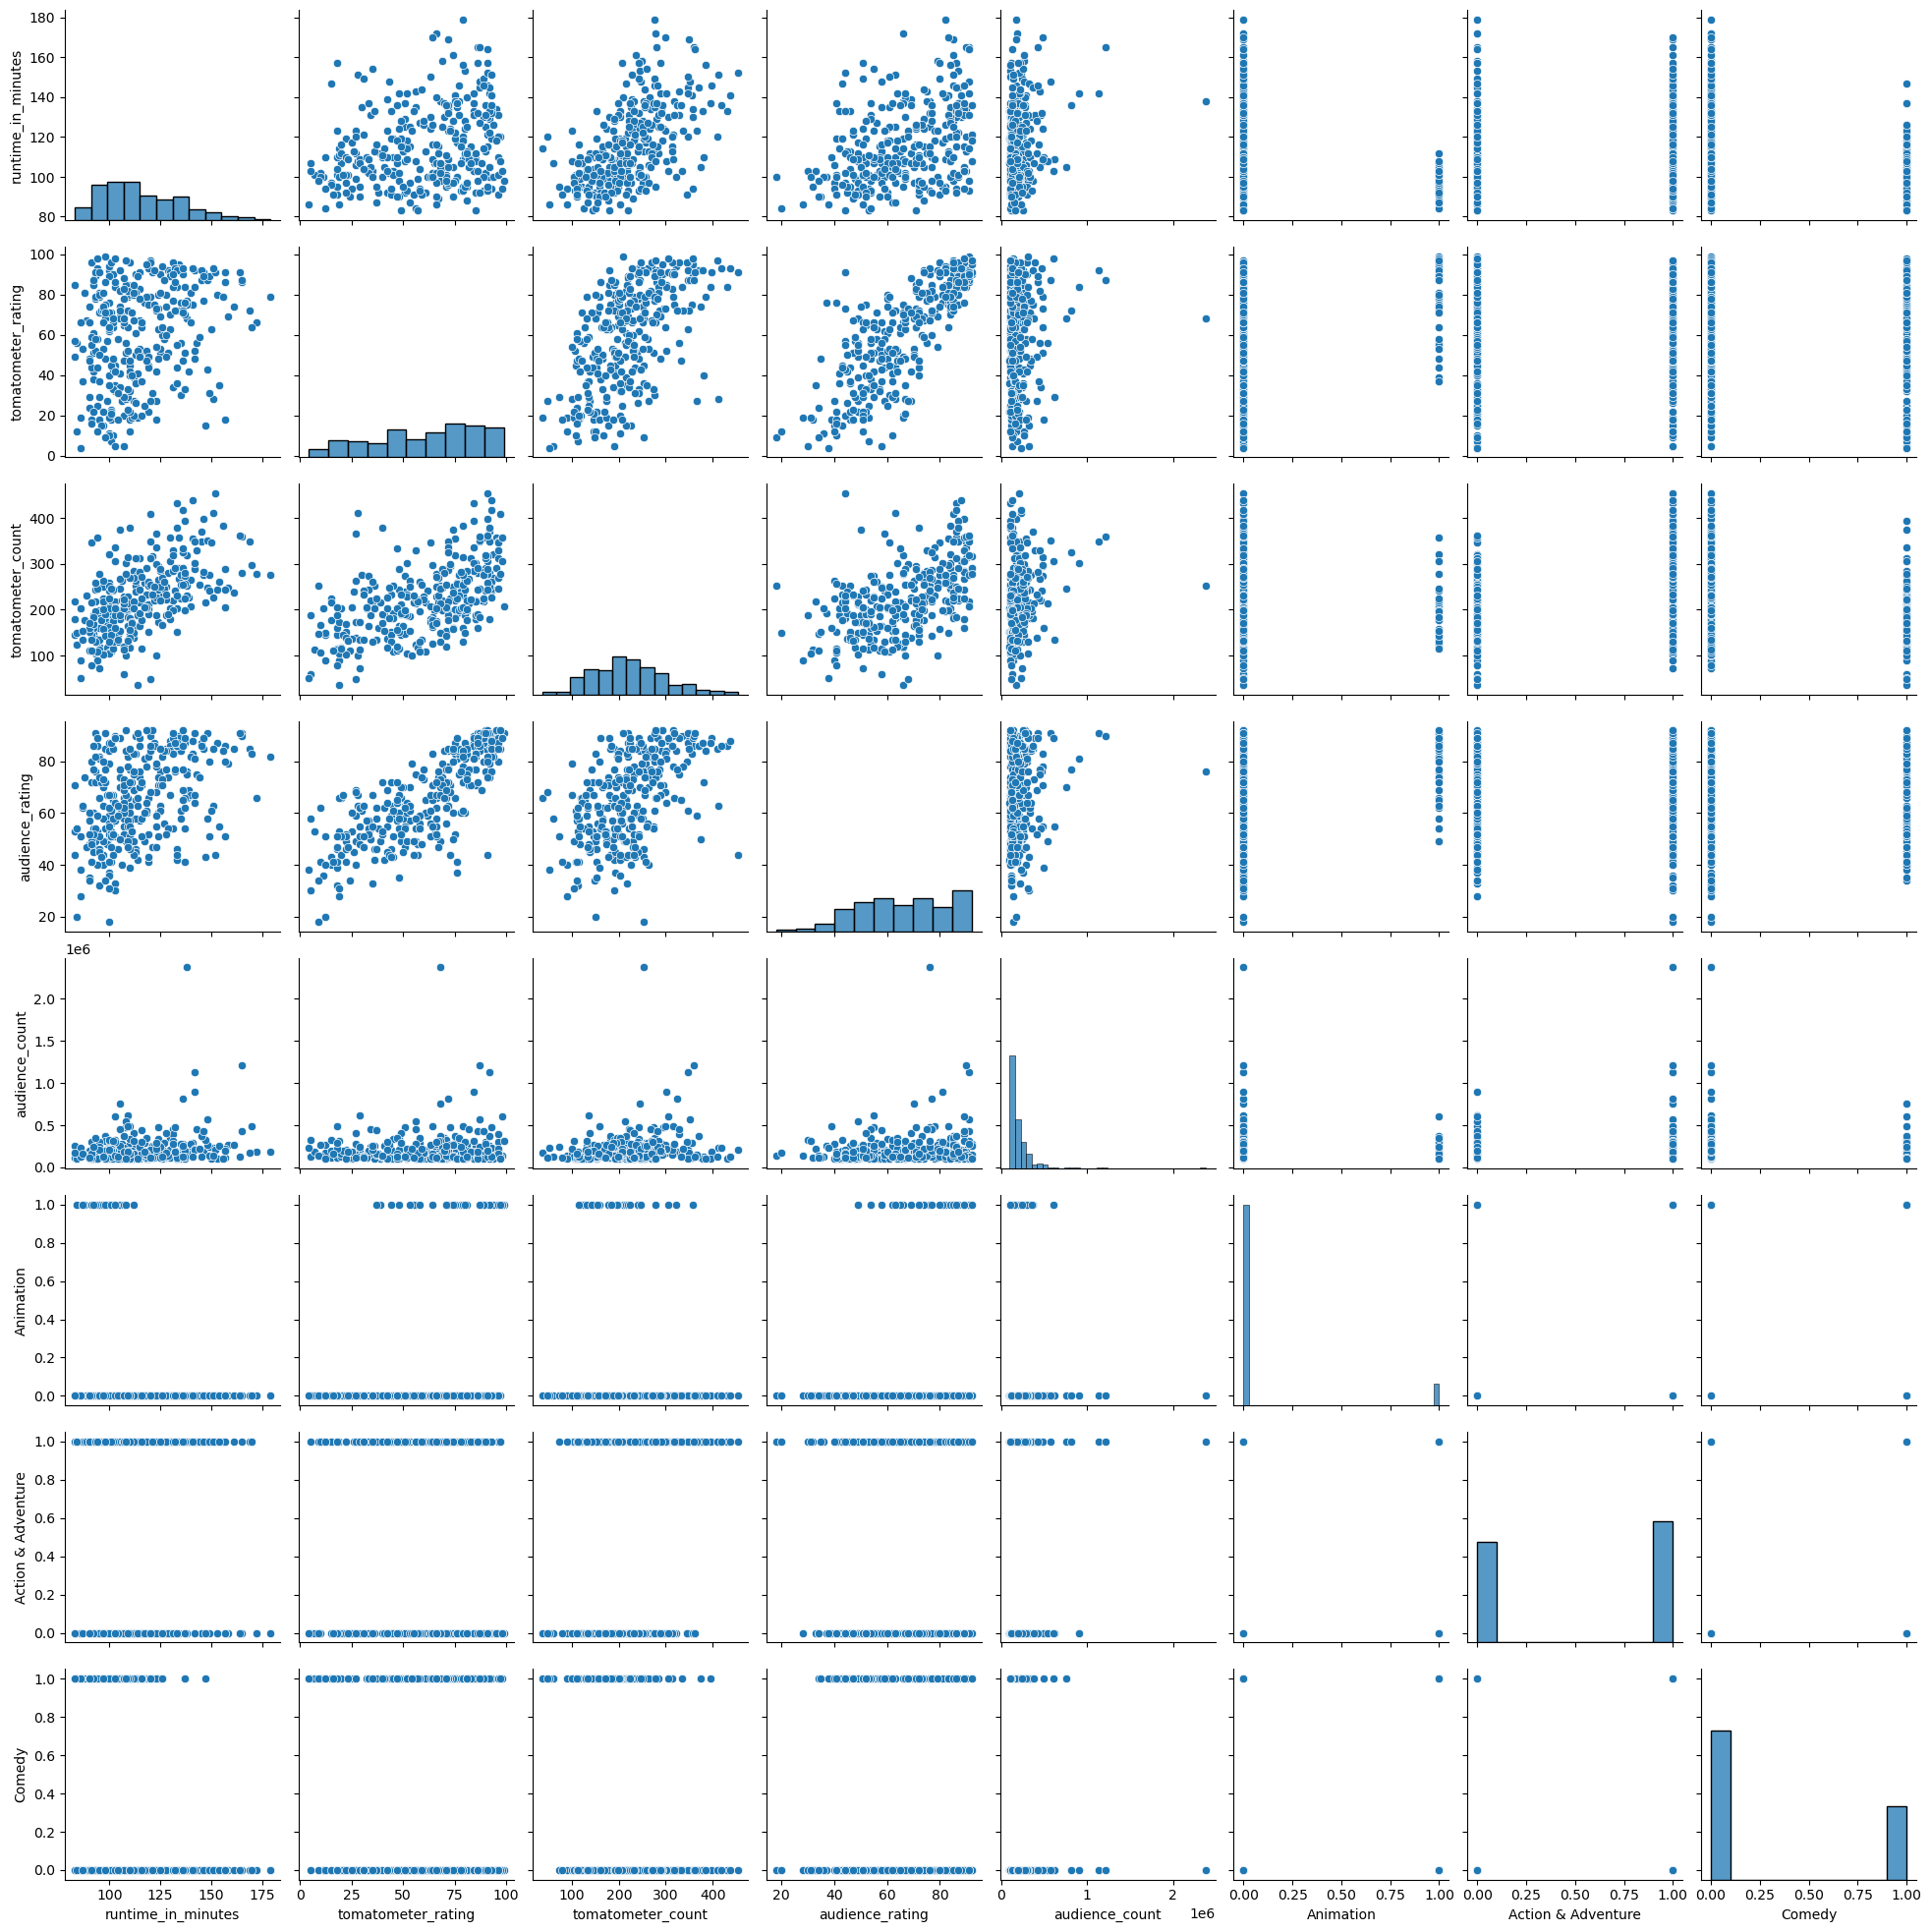

In [150]:
sns.pairplot(movies_popular)

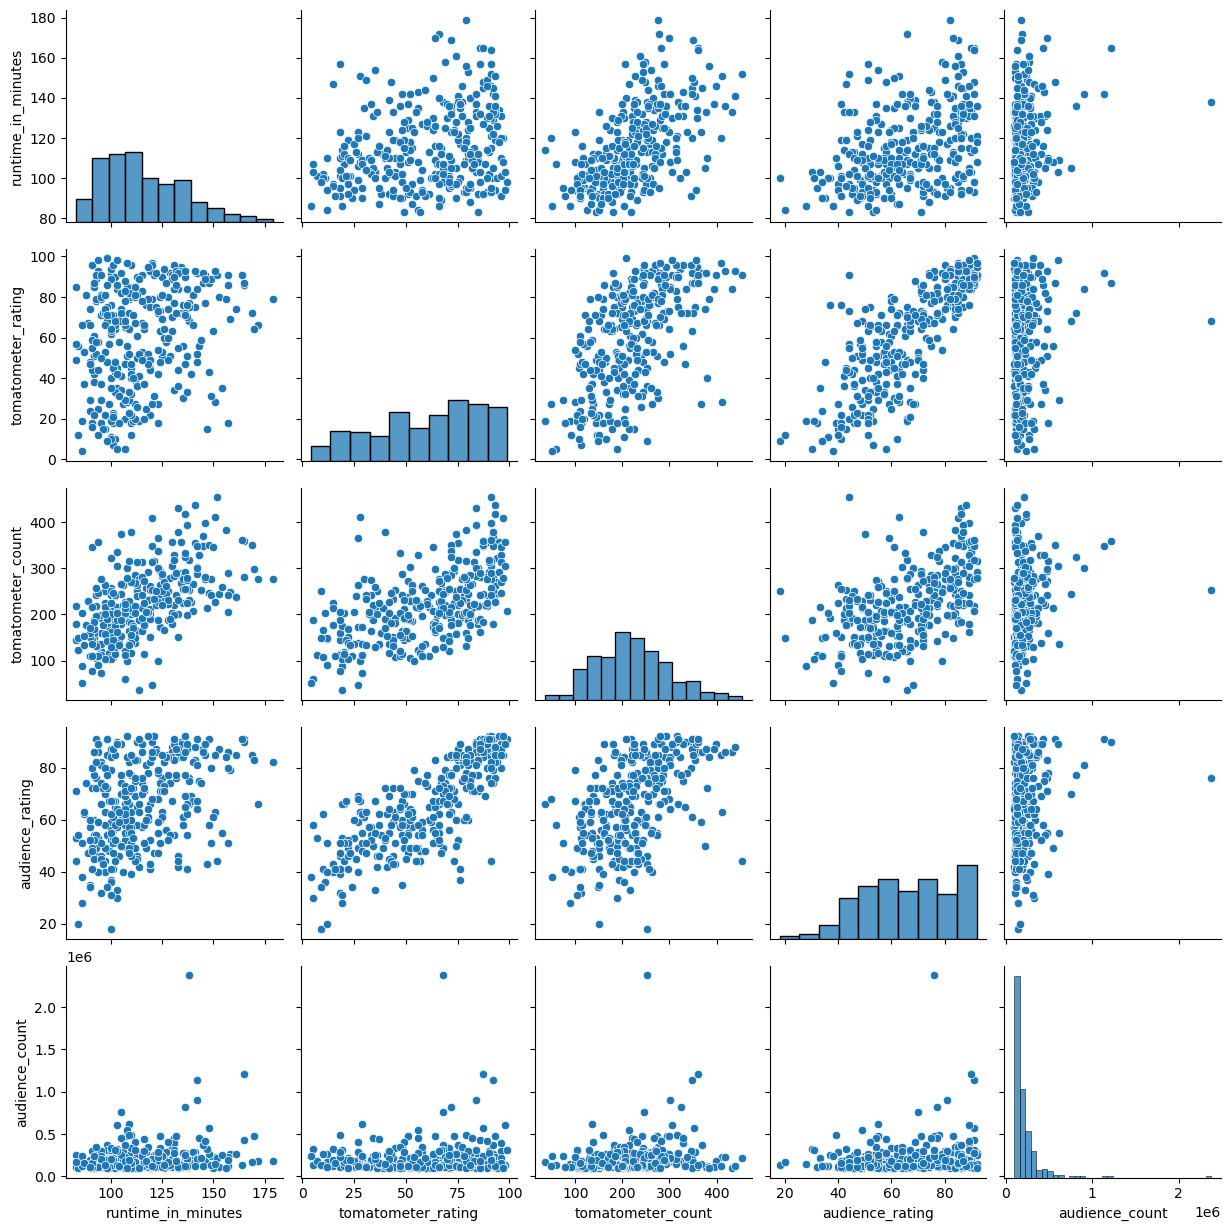

In [151]:
sns.pairplot(movies_popular.iloc[:, :-3]); #exclude not necessary columns (last 3)

What insights can you gather from this pair plot?
* How do the critic ratings (tomatometer_rating) compare with the audience ratings (compare the histograms)?
* What are some surprising findings about the run times of movies compared with other fields (look at the scatter plots)?
* What is the most popular movie by far in terms of the number of audience ratings?

In [101]:
popular_movies.head(2)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
2280,How to Train Your Dragon,PG,"Animation, Kids & Family, Science Fiction & Fa...",2010-03-26,98.0,99,208,91.0,312342.0,1,0,0
2431,Inside Out,PG,"Animation, Kids & Family",2015-06-19,94.0,98,357,89.0,136125.0,1,0,0


In [105]:
popular_movies.sort_values('audience_count', ascending=False).head(2)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
57,Shutter Island,R,"Action & Adventure, Drama, Mystery & Suspense",2010-02-19,138.0,68,253,76.0,2373625.0,0,1,0
4706,The Dark Knight Rises,PG-13,"Action & Adventure, Drama, Mystery & Suspense",2012-07-20,165.0,87,360,90.0,1210957.0,0,1,0


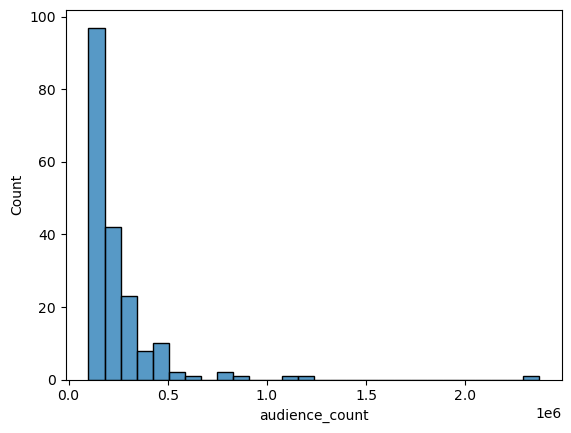

In [104]:
sns.histplot(popular_movies['audience_count']);

In [152]:
movies_popular.sort_values('audience_count', ascending=False).head(2)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
57,Shutter Island,R,"Action & Adventure, Drama, Mystery & Suspense",2010-02-19,138.0,68,253,76.0,2373625.0,0,1,0
4706,The Dark Knight Rises,PG-13,"Action & Adventure, Drama, Mystery & Suspense",2012-07-20,165.0,87,360,90.0,1210957.0,0,1,0


In [153]:
movies_popular[movies_popular['audience_count'] > 1000000]

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
57,Shutter Island,R,"Action & Adventure, Drama, Mystery & Suspense",2010-02-19,138.0,68,253,76.0,2373625.0,0,1,0
3091,Marvel's The Avengers,PG-13,"Action & Adventure, Science Fiction & Fantasy",2012-05-04,142.0,92,348,91.0,1134955.0,0,1,0
4706,The Dark Knight Rises,PG-13,"Action & Adventure, Drama, Mystery & Suspense",2012-07-20,165.0,87,360,90.0,1210957.0,0,1,0
